   Unnamed: 0     category   price  quantity                  order_date  \
0           0        Books   45.95         4  2024-04-20 14:59:58.897063   
1           1  Electronics  403.17         3  2024-04-20 14:59:58.897063   
2           2       Beauty  317.45         2  2024-04-20 14:59:58.897063   
3           3         Home   24.08         3  2024-04-20 14:59:58.897063   
4           4     Clothing  494.90         1  2024-04-20 14:59:58.897063   

                shipping_date delivery_status payment_method device_type  \
0  2024-04-27 14:59:58.897063         Shipped         PayPal      Mobile   
1  2024-04-22 14:59:58.897063       Delivered         PayPal      Mobile   
2  2024-04-27 14:59:58.897063         Shipped    Credit Card      Mobile   
3  2024-04-24 14:59:58.897063         Shipped         PayPal      Tablet   
4  2024-04-25 14:59:58.897063       Delivered         PayPal      Tablet   

       channel customer_segment  order_month  order_day  order_hour  \
0  Paid Search 

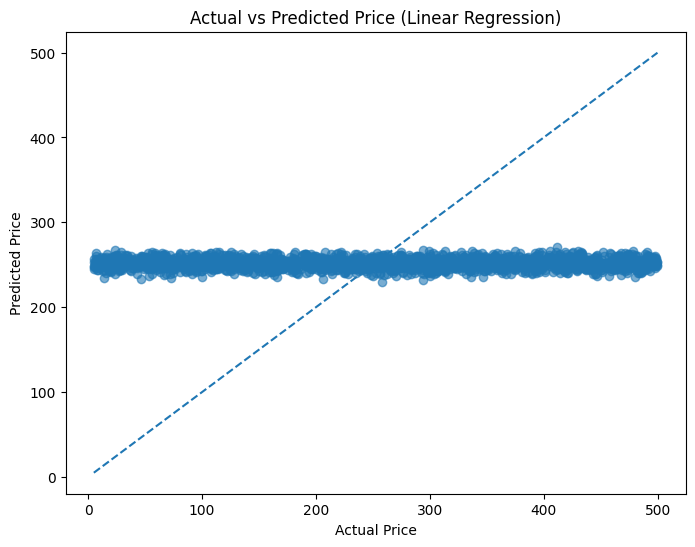


===== SAMPLE PREDICTIONS =====
   Actual Price  Predicted Price
0        432.96       255.067667
1        352.49       255.823239
2        315.73       251.275092
3        214.16       243.377471
4         52.33       251.681746
5        394.88       252.280583
6        353.01       253.114171
7        389.93       247.724953
8        226.72       261.698880
9        149.03       246.825910


In [5]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ---------------------------------------
# load the cleaned csv
# ---------------------------------------
df = pd.read_csv("../data/cleaned_ecommerce_order.csv")
print(df.head())

# ---------------------------------------
# define feature and target
# ---------------------------------------
X = df.drop("price", axis=1)
y = df["price"]

# ---------------------------------------
# train test split
# ---------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------------------------------
# load the preprocessor
# ---------------------------------------
preprocessor = joblib.load("../artifacts/preprocessor.joblib")

# ---------------------------------------
# model 01 - create the lienear model
# ---------------------------------------
linear_model = Pipeline(steps=[
    ("preprosessor", preprocessor),
    ("regressor", LinearRegression())
])

# ---------------------------------------
# train the model
# ---------------------------------------
linear_model.fit(X_train, y_train)

# ---------------------------------------
# predict
# ---------------------------------------
y_pred_lr = linear_model.predict(X_test)


# ---------------------------------------
# mse and mae
# ---------------------------------------
mse_lr = mean_squared_error(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)
print("MSE:", mse_lr)
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)


# ---------------------------------------
# model 02 - random forest regressor
# ---------------------------------------
random_forest_regressor = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(random_state=42))
])

# ---------------------------------------
# hyperparameter tuning
# ---------------------------------------
param_grid = {
    "regressor__n_estimators": [100, 200],
    "regressor__max_depth": [10, 20, None],
    "regressor__min_samples_split": [2, 5],
    "regressor__min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    estimator=random_forest_regressor,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("\nBest Parameters for Random Forest:")
print(grid_search.best_params_)

best_rf = grid_search.best_estimator_
y_pred_rf = best_rf.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("\n===== RANDOM FOREST RESULTS =====")
print("MSE :", mse_rf)
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R2  :", r2_rf)

# ---------------------------------------
# cross validation
# ---------------------------------------
cv_scores_lr = cross_val_score(
    linear_model, X, y, cv=5, scoring="neg_mean_squared_error"
)
cv_rmse_lr = np.sqrt(-cv_scores_lr)

cv_scores_rf = cross_val_score(
    best_rf, X, y, cv=5, scoring="neg_mean_squared_error"
)
cv_rmse_rf = np.sqrt(-cv_scores_rf)

print("\n===== CROSS VALIDATION =====")
print("Linear Regression RMSE values:", cv_rmse_lr)
print("Linear Regression Mean RMSE :", cv_rmse_lr.mean())

print("\nRandom Forest RMSE values:", cv_rmse_rf)
print("Random Forest Mean RMSE :", cv_rmse_rf.mean())

# ---------------------------------------
# select best model
# ---------------------------------------
if rmse_lr < rmse_rf:
    final_model = linear_model
    best_model_name = "Linear Regression"
    final_predictions = y_pred_lr
else:
    final_model = best_rf
    best_model_name = "Random Forest"
    final_predictions = y_pred_rf

print("\nBest Model Selected:", best_model_name)

# ---------------------------------------
# actual vs predicted plot
# ---------------------------------------
plt.figure(figsize=(8, 6))
plt.scatter(y_test, final_predictions, alpha=0.6)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(f"Actual vs Predicted Price ({best_model_name})")

min_val = min(y_test.min(), final_predictions.min())
max_val = max(y_test.max(), final_predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.show()

# ---------------------------------------
# sample predictions
# ---------------------------------------
results_df = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": final_predictions
})

print("\n===== SAMPLE PREDICTIONS =====")
print(results_df.head(10))


In [ ]:
# ---------------------------------------
# classification model
# ---------------------------------------
from sklearn.linear_model import LogisticRegression


X = df.drop(columns=["customer_segment"])
y = df["customer_segment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        solver="lbfgs",
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])


